In [11]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np 
from tqdm import tqdm
import stackview as sv
from functools import partial

from codex.data.codex_dataset import CodexDataset
from codex.preprocessing.nodes import OmeTifExportNode
from codex.preprocessing.sopa_exporter import SopaExporter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
out_dir = Path("../../outputs/")
out_dir.mkdir(parents=True, exist_ok=True)

node = OmeTifExportNode(
    algorithm=partial(SopaExporter, remove_markers=["Blank", "Empty"], save_zarr=True, save_explorer=False, scale_factors=None, rename_dict=None),
    ds=CodexDataset(
        root_dir=Path("../../outputs/preprocess/2025-10-15/18-30-07/background_correction"),
        mode="raw",
        lazy_loading=True,
        read_markers=False,
    ),
    out_dir=out_dir,
)

In [13]:
node.ds.pretty_print()

+----+---------+----------+--------+----------+--------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    |   cycle |   region |   tile |   zslice | channel      | img_path                                                                                                                                                                                                                                                                                                                                                                                                                             |
|----+---------+----------+-

In [14]:
node.run()

INFO     The Zarr backing store has been changed from None the new file path: ../../outputs/ome/reg001.zarr        


In [15]:
import spatialdata as sd
import spatialdata_plot

sdata = sd.read_zarr("../../outputs/ome/reg001.zarr")
sdata

/home/antonio/anaconda3/envs/codex/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


SpatialData object, with associated Zarr store: /home/antonio/projects/codex/outputs/ome/reg001.zarr
└── Images
      └── 'image': DataArray[cyx] (15, 13499, 11622)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images)

INFO     Rasterizing image for faster rendering.                                                                   


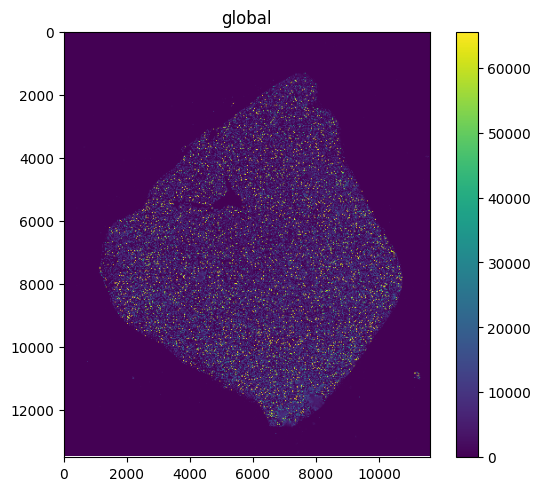

In [21]:
sdata.pl.render_images(channel="DAPI-01").pl.show()